# Fitness Coach: Calorie Prediction Models

This notebook prepares the dataset and trains regression models for **required calories** and **calories burned**. All preprocessing is fit on training data only.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load data
In this step, we load the dataset required for our project. 

To ensure this notebook is fully reproducible and easy to run for anyone without requiring manual downloads, the dataset is hosted on Google Drive. We utilize the `gdown` library to bypass Google Drive's large-file virus scan warnings and fetch the data directly into our environment. Finally, we use `pandas` to read the downloaded CSV file into a DataFrame.

In [5]:
import gdown

file_id = '1AM92bxS25Uv1a8LYMJ9voQ7l03ty740X'
url = f'https://drive.google.com/uc?id={file_id}'

output_file = 'my_dataset.csv'
gdown.download(url, output_file, quiet=False)

df = pd.read_csv(output_file)

Downloading...
From: https://drive.google.com/uc?id=1AM92bxS25Uv1a8LYMJ9voQ7l03ty740X
To: c:\Users\ahmed\Downloads\Fitness Coach\my_dataset.csv
100%|██████████| 75.6M/75.6M [00:24<00:00, 3.03MB/s]


## 3. Initial data inspection

In [4]:
df.head()

,ID,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,calories_burned,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
0,1,56,F,165.3,50.55,18.50,Dancing,42.1,Low,3.3,...,69.5,110.7,72.9,5.37,6.6,4,1.5,Never,NaN,0.04
1,2,56,F,165.3,55.38,20.27,Swimming,66.9,Low,2.9,...,69.5,110.7,72.9,5.39,8.1,3,1.8,Never,NaN,0.07
2,3,56,F,165.3,56.49,20.68,Swimming,20.0,Medium,2.6,...,69.5,110.7,72.9,5.42,6.2,5,2.7,Never,NaN,0.09
3,4,56,F,165.3,52.23,19.12,Weight Training,23.5,Medium,10.7,...,69.5,110.7,72.9,5.44,7.2,4,2.6,Never,NaN,0.21
4,5,56,F,165.3,53.96,19.75,Swimming,75.0,Medium,12.7,...,69.5,110.7,72.9,5.47,7.1,7,1.5,Never,NaN,0.33


In [4]:
df.tail()

,ID,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,calories_burned,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
687696,687697,38,F,165.7,57.06,20.78,Basketball,109.6,Medium,13.2,...,66.5,127.0,75.5,11.29,7.4,4,1.9,Never,NaN,17.13
687697,687698,38,F,165.7,55.24,20.12,Basketball,145.3,Low,6.3,...,66.5,127.0,75.5,11.31,8.5,5,2.6,Never,NaN,17.16
687698,687699,38,F,165.7,60.26,21.95,Yoga,84.9,Low,9.1,...,66.5,127.0,75.5,11.34,8.2,4,1.8,Never,NaN,17.26
687699,687700,38,F,165.7,59.30,21.60,Basketball,107.1,Medium,32.6,...,66.5,127.0,75.5,11.36,8.5,6,2.1,Never,NaN,17.39
687700,687701,38,F,165.7,57.56,20.96,Yoga,88.3,High,3.8,...,66.5,127.0,75.5,11.39,7.4,3,2.0,Never,NaN,17.43


In [5]:

met_values = {
    'Yoga': {'Low': 2.5, 'Medium': 3.0, 'High': 4.0},
    'Walking': {'Low': 2.8, 'Medium': 3.5, 'High': 4.5},
    'Running': {'Low': 7.0, 'Medium': 9.0, 'High': 11.5},
    'Cycling': {'Low': 4.0, 'Medium': 6.8, 'High': 8.5},
    'Swimming': {'Low': 6.0, 'Medium': 8.0, 'High': 10.0},
    'Basketball': {'Low': 6.0, 'Medium': 8.0, 'High': 10.0},
    'Tennis': {'Low': 5.0, 'Medium': 7.3, 'High': 8.0},
    'Weight Training': {'Low': 3.5, 'Medium': 5.0, 'High': 6.0},
    'HIIT': {'Low': 8.0, 'Medium': 10.0, 'High': 12.0},
    'Dancing': {'Low': 4.0, 'Medium': 5.5, 'High': 7.5}
}

def calculate_calories(row):
    met = met_values.get(row["activity_type"], {}).get(row["intensity"], 5.0)

    calories = (met * 3.5 * row["weight_kg"] * row["duration_minutes"]) / 200

    return round(calories, 1)

df["calories_burned"] = df.apply(calculate_calories, axis=1)

In [6]:
df["activity_type"].unique()

array(['Dancing', 'Swimming', 'Weight Training', 'HIIT', 'Running',
       'Walking', 'Tennis', 'Basketball', 'Yoga', 'Cycling'], dtype=object)

In [7]:
df.head()

,ID,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,calories_burned,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
0,1,56,F,165.3,50.55,18.50,Dancing,42.1,Low,149.0,...,69.5,110.7,72.9,5.37,6.6,4,1.5,Never,NaN,0.04
1,2,56,F,165.3,55.38,20.27,Swimming,66.9,Low,389.0,...,69.5,110.7,72.9,5.39,8.1,3,1.8,Never,NaN,0.07
2,3,56,F,165.3,56.49,20.68,Swimming,20.0,Medium,158.2,...,69.5,110.7,72.9,5.42,6.2,5,2.7,Never,NaN,0.09
3,4,56,F,165.3,52.23,19.12,Weight Training,23.5,Medium,107.4,...,69.5,110.7,72.9,5.44,7.2,4,2.6,Never,NaN,0.21
4,5,56,F,165.3,53.96,19.75,Swimming,75.0,Medium,566.6,...,69.5,110.7,72.9,5.47,7.1,7,1.5,Never,NaN,0.33


In [8]:
df.shape

(687701, 22)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        687701 non-null  int64  
 1   age                       687701 non-null  int64  
 2   gender                    687701 non-null  object 
 3   height_cm                 687701 non-null  float64
 4   weight_kg                 687701 non-null  float64
 5   bmi                       687701 non-null  float64
 6   activity_type             687701 non-null  object 
 7   duration_minutes          687701 non-null  float64
 8   intensity                 687701 non-null  object 
 9   calories_burned           687701 non-null  float64
 10  daily_steps               687701 non-null  int64  
 11  avg_heart_rate            687701 non-null  int64  
 12  resting_heart_rate        687701 non-null  float64
 13  blood_pressure_systolic   687701 non-null  f

In [10]:
df.isnull().sum()

,0
ID,0
age,0
gender,0
height_cm,0
weight_kg,0
bmi,0
activity_type,0
duration_minutes,0
intensity,0
calories_burned,0


## 4. Data cleaning

In [11]:
df.drop(columns=["health_condition"], inplace=True)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,687701.0,343851.000000,198522.323072,1.00,171926.00,343851.00,515776.00,687701.00
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,61.728155,8.547730,39.76,55.50,61.06,67.31,98.11
bmi,687701.0,21.663562,1.939251,18.50,20.06,21.64,23.27,24.90
duration_minutes,687701.0,74.026662,35.095472,20.00,46.30,72.80,99.50,152.10
calories_burned,687701.0,511.390298,336.324127,35.70,251.40,435.00,697.70,2932.50
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
resting_heart_rate,687701.0,70.010547,5.074563,51.10,66.50,70.00,73.50,87.10


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[df["daily_steps"] < 0]

,ID,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,calories_burned,...,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,fitness_level
207781,207782,59,Other,164.5,51.14,18.90,Tennis,82.3,Low,368.3,...,101,80.7,119.4,75.0,10.84,7.0,5,2.9,Former,16.52
360838,360839,62,F,160.3,53.74,20.91,Walking,84.8,High,358.9,...,132,73.7,133.5,65.4,11.11,8.7,4,2.0,Never,16.16


In [15]:
df.drop(df[df["daily_steps"] < 0].index, inplace=True)
df[df["daily_steps"] < 0]

,ID,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,calories_burned,...,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,fitness_level


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,687699.0,343851.173159,198522.542885,1.00,171925.50,343851.00,515776.50,687701.00
age,687699.0,41.658547,13.581752,18.00,30.00,42.00,53.00,64.00
height_cm,687699.0,168.587717,9.140818,145.00,161.70,168.20,175.30,198.50
weight_kg,687699.0,61.728182,8.547728,39.76,55.50,61.06,67.31,98.11
bmi,687699.0,21.663567,1.939251,18.50,20.06,21.64,23.27,24.90
duration_minutes,687699.0,74.026635,35.095520,20.00,46.30,72.80,99.50,152.10
calories_burned,687699.0,511.390728,336.324522,35.70,251.40,435.00,697.70,2932.50
daily_steps,687699.0,8628.396739,2054.703791,36.00,7203.00,8607.00,10027.00,17241.00
avg_heart_rate,687699.0,131.454209,17.814732,82.00,118.00,130.00,144.00,206.00
resting_heart_rate,687699.0,70.010526,5.074552,51.10,66.50,70.00,73.50,87.10


In [17]:
df.drop("ID", axis=1, inplace=True)
df.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'activity_type',
       'duration_minutes', 'intensity', 'calories_burned', 'daily_steps',
       'avg_heart_rate', 'resting_heart_rate', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'endurance_level', 'sleep_hours',
       'stress_level', 'hydration_level', 'smoking_status', 'fitness_level'],
      dtype='object')

## 5. EDA (Exploratory data analysis)

In [18]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)}")

age: 0
height_cm: 460
weight_kg: 3969
bmi: 0
duration_minutes: 0
calories_burned: 14988
daily_steps: 3092
avg_heart_rate: 1867
resting_heart_rate: 3738
blood_pressure_systolic: 3602
blood_pressure_diastolic: 6107
endurance_level: 1706
sleep_hours: 5897
stress_level: 0
hydration_level: 0
fitness_level: 0


In [19]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_columns)

Index(['age', 'height_cm', 'weight_kg', 'bmi', 'duration_minutes',
       'calories_burned', 'daily_steps', 'avg_heart_rate',
       'resting_heart_rate', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'endurance_level', 'sleep_hours',
       'stress_level', 'hydration_level', 'fitness_level'],
      dtype='object')


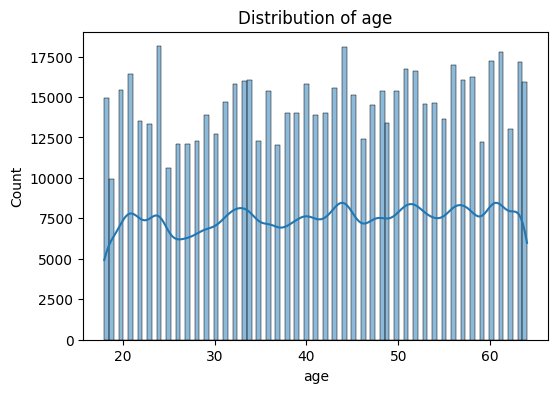

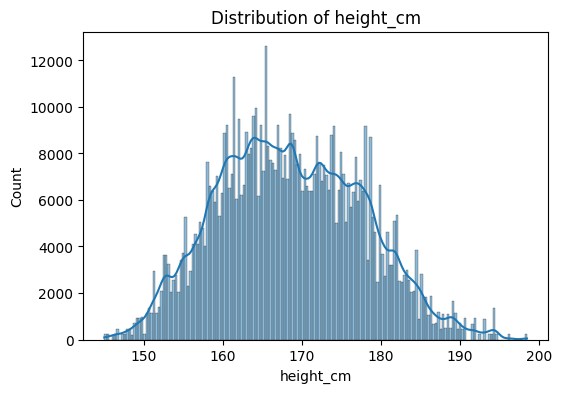

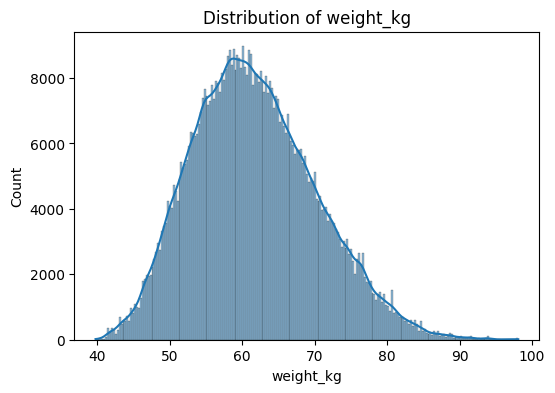

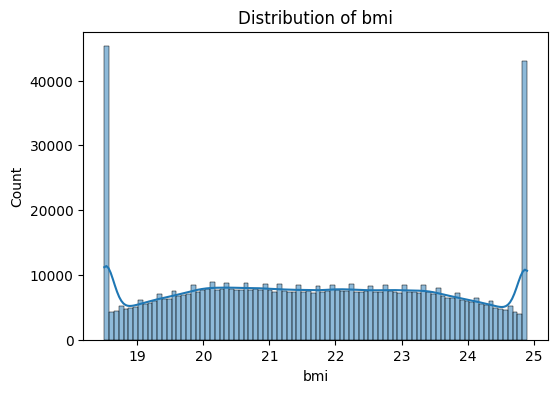

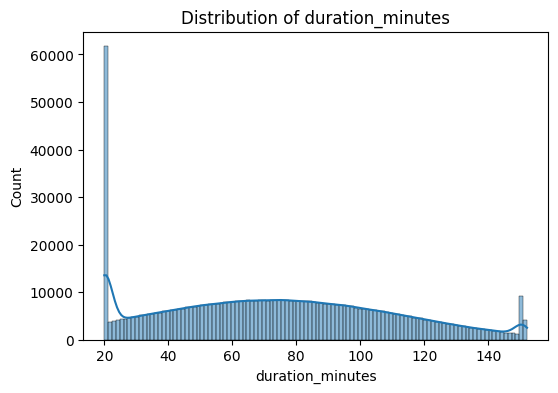

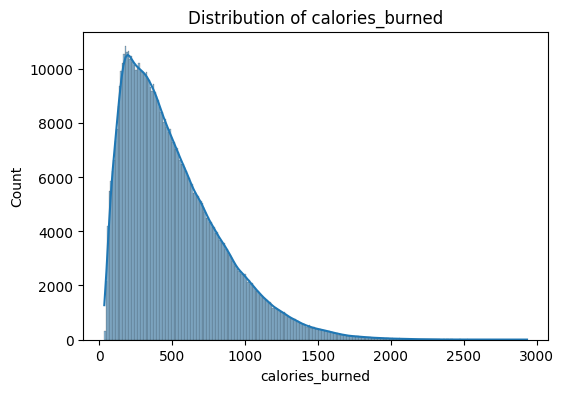

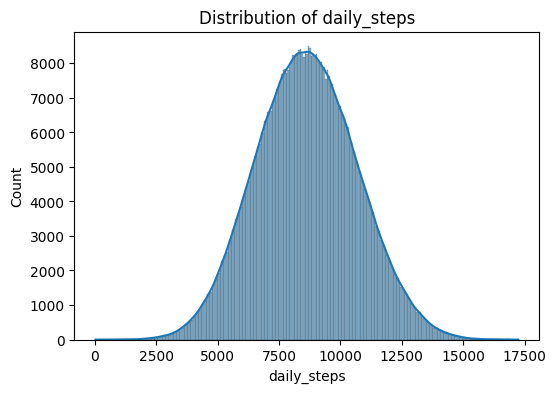

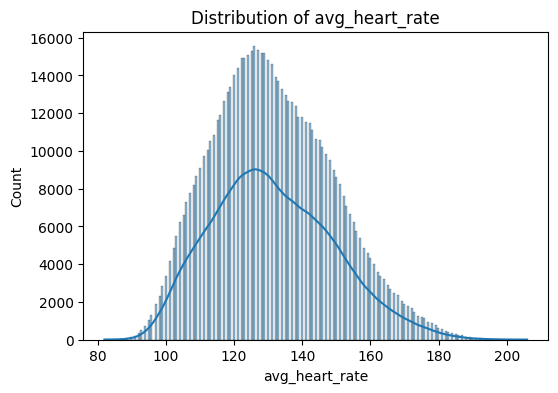

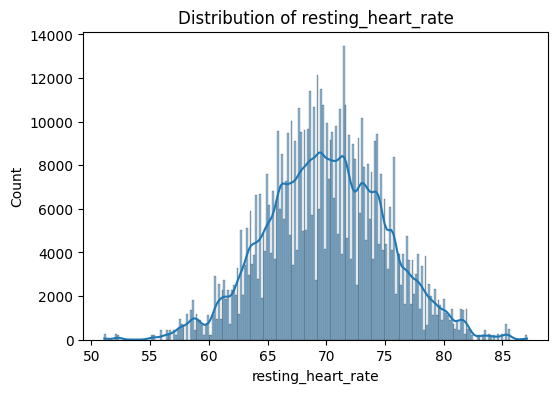

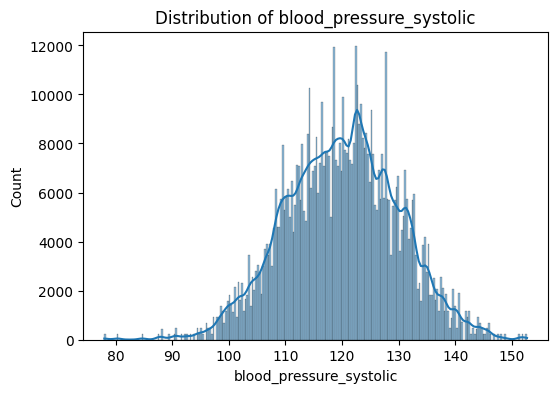

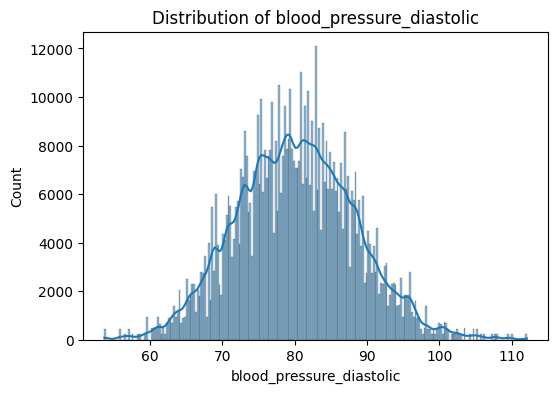

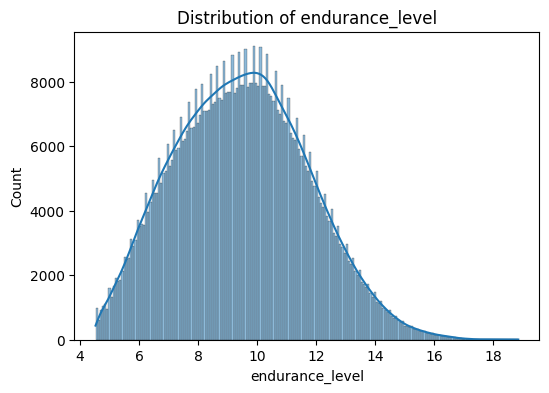

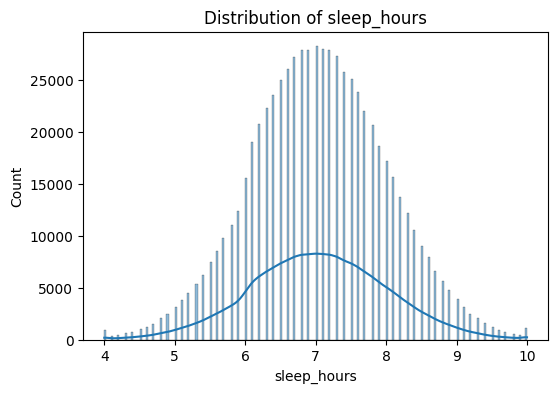

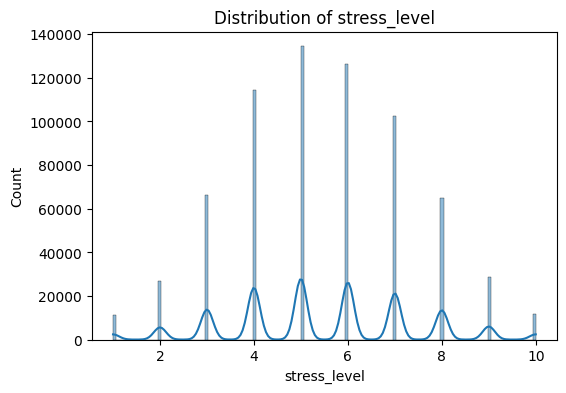

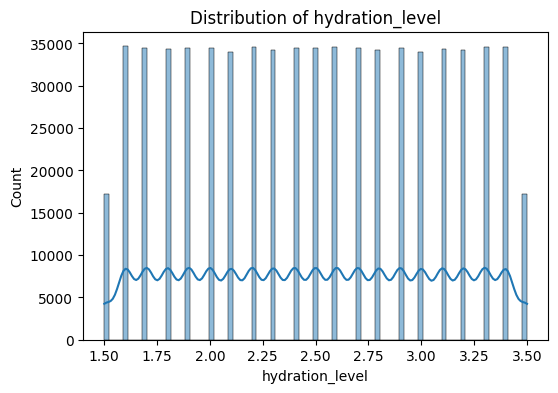

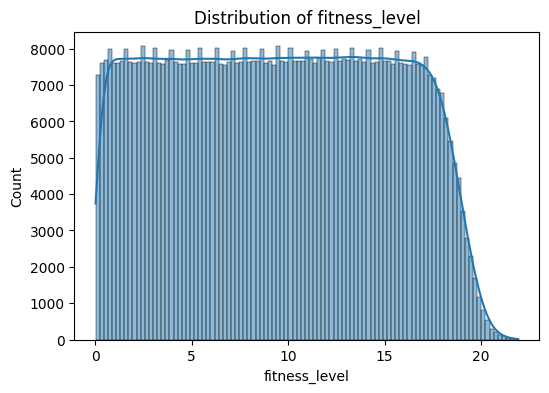

In [20]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [21]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'activity_type', 'intensity', 'smoking_status'], dtype='object')


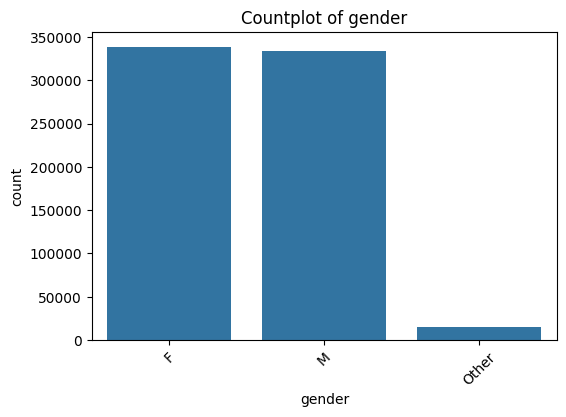

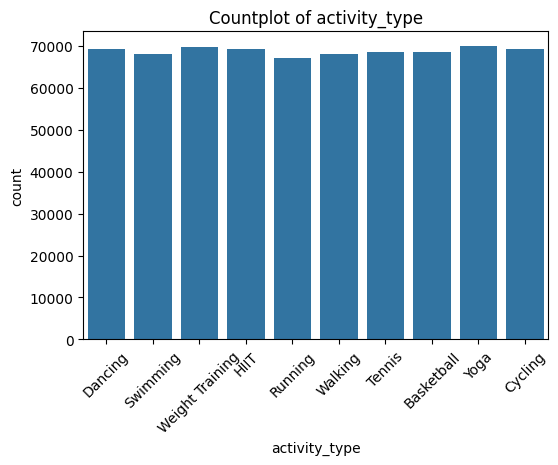

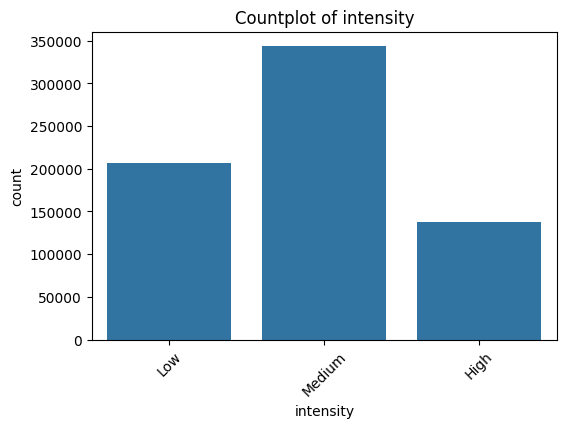

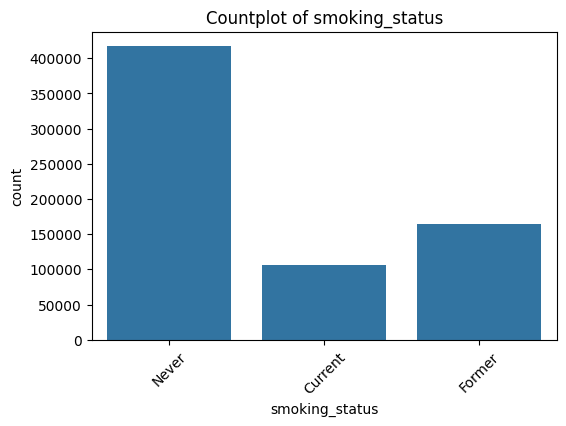

In [22]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

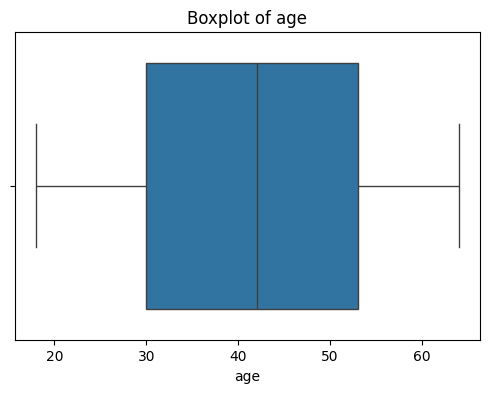

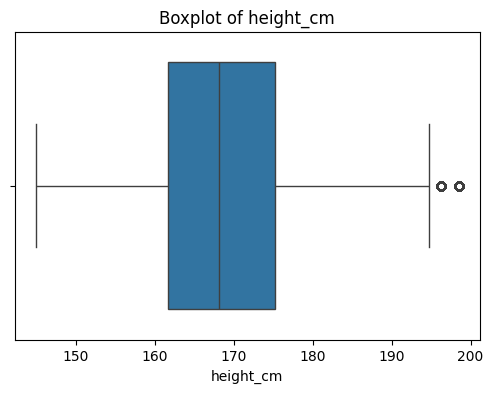

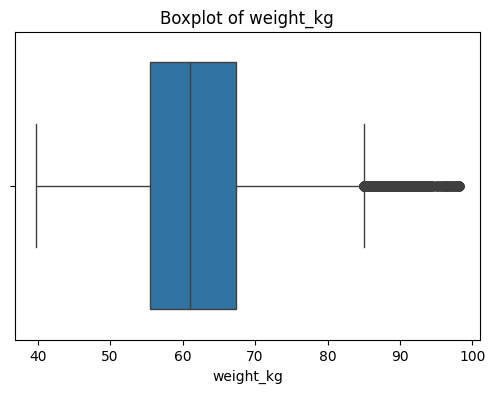

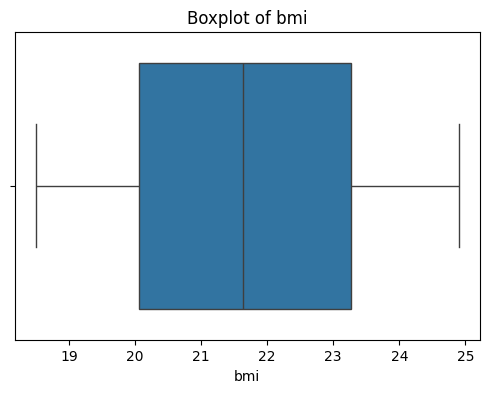

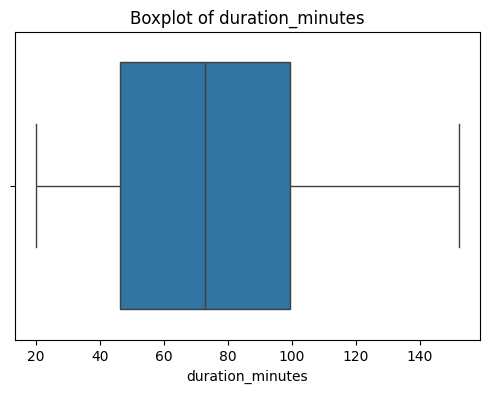

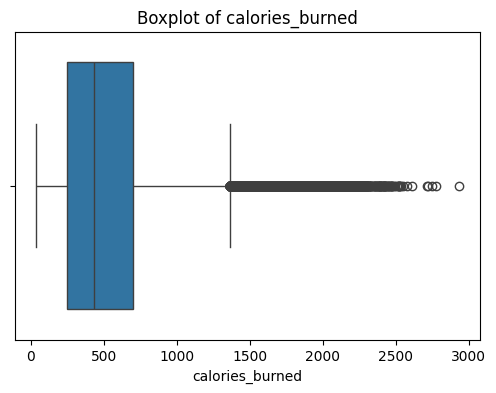

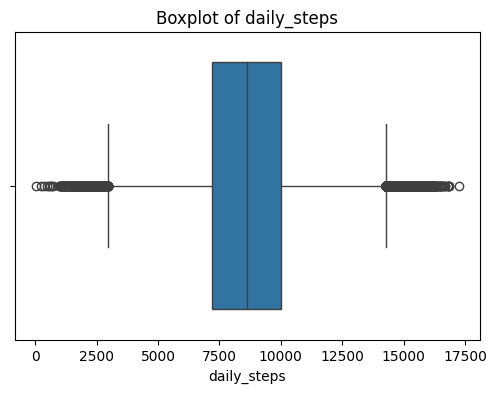

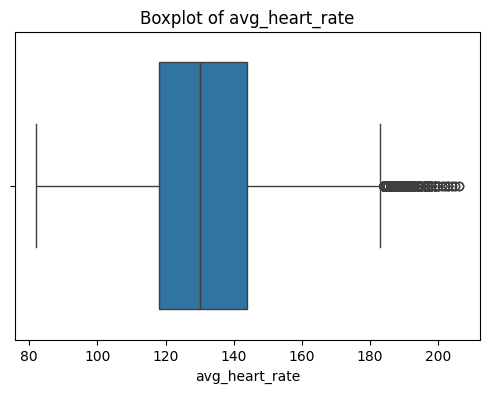

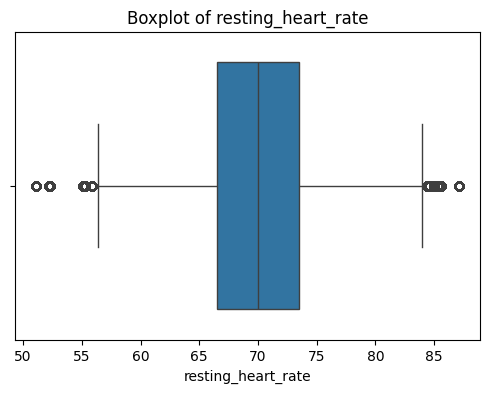

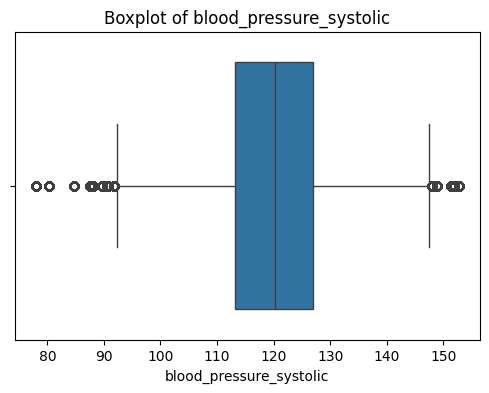

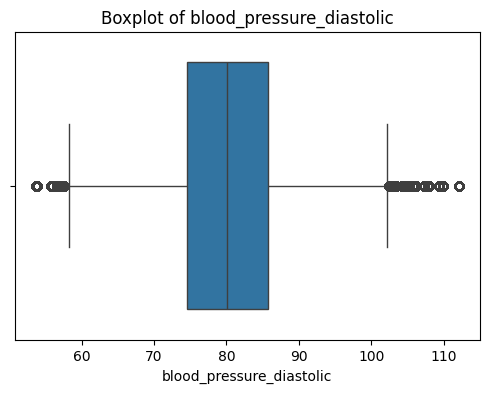

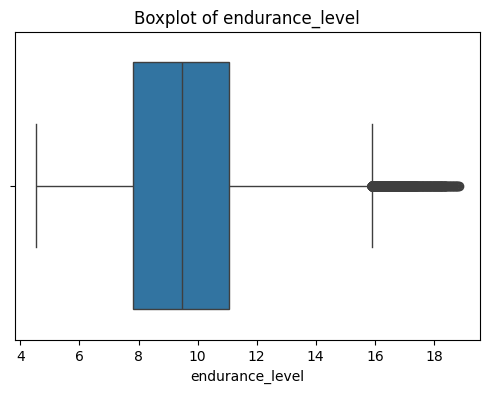

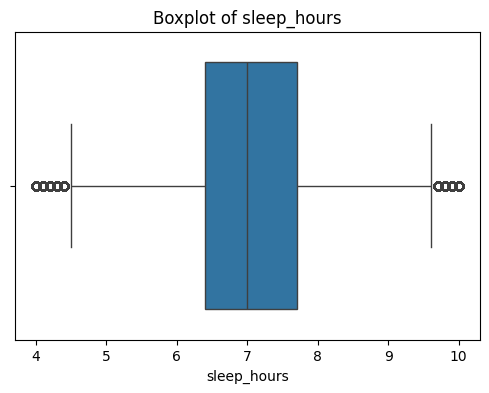

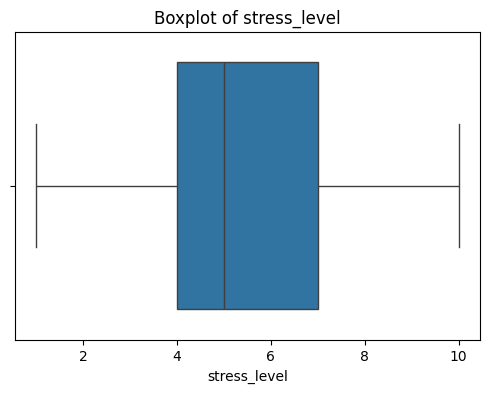

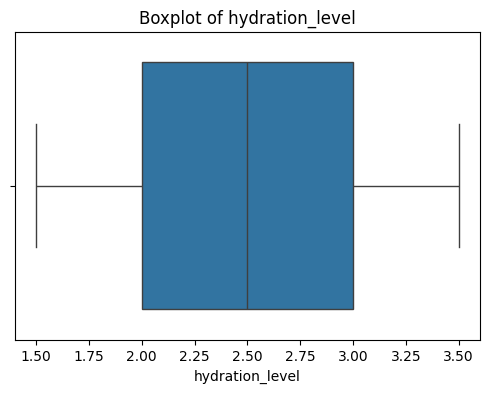

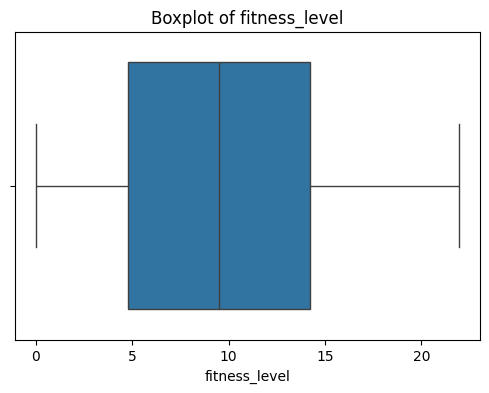

In [23]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [24]:
corr = df.select_dtypes(include=["int64","float64"]).corr()
corr

,age,height_cm,weight_kg,bmi,duration_minutes,calories_burned,daily_steps,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,fitness_level
age,1.000000,0.008303,0.011420,0.010261,0.000324,0.002955,-0.000677,-0.564767,-0.003738,-0.015983,-0.008385,0.032012,-0.000552,0.000987,0.000979,0.002717
height_cm,0.008303,1.000000,0.758838,-0.041479,0.000126,0.160999,-0.000598,-0.004639,0.002923,-0.015440,-0.002396,0.472810,-0.000323,0.001233,-0.000259,0.001470
weight_kg,0.011420,0.758838,1.000000,0.615023,0.000545,0.211222,-0.000830,-0.006429,-0.013874,0.005434,-0.010091,0.355787,-0.001248,0.001619,-0.000129,-0.000600
bmi,0.010261,-0.041479,0.615023,1.000000,0.000586,0.128953,-0.000460,-0.005755,-0.027701,0.023862,-0.013445,-0.025734,-0.001559,0.000961,0.000267,-0.002487
duration_minutes,0.000324,0.000126,0.000545,0.000586,1.000000,0.720701,-0.319792,0.000664,-0.001865,-0.000858,-0.000365,0.536427,-0.002688,0.002481,-0.001774,0.699834
calories_burned,0.002955,0.160999,0.211222,0.128953,0.720701,1.000000,-0.231035,0.192532,-0.006420,-0.000520,-0.001186,0.462605,-0.002809,0.003491,-0.001993,0.504665
daily_steps,-0.000677,-0.000598,-0.000830,-0.000460,-0.319792,-0.231035,1.000000,-0.000495,-0.000787,0.000445,0.000751,-0.343978,0.001035,-0.001680,0.000373,-0.449570
avg_heart_rate,-0.564767,-0.004639,-0.006429,-0.005755,0.000664,0.192532,-0.000495,1.000000,0.001782,0.008187,0.004924,-0.017418,-0.000343,0.000205,0.000177,0.000375
resting_heart_rate,-0.003738,0.002923,-0.013874,-0.027701,-0.001865,-0.006420,-0.000787,0.001782,1.000000,-0.009141,0.034190,-0.000299,-0.001158,0.000005,0.002901,0.004152
blood_pressure_systolic,-0.015983,-0.015440,0.005434,0.023862,-0.000858,-0.000520,0.000445,0.008187,-0.009141,1.000000,0.000143,0.009457,0.000946,0.001602,0.001811,0.000955


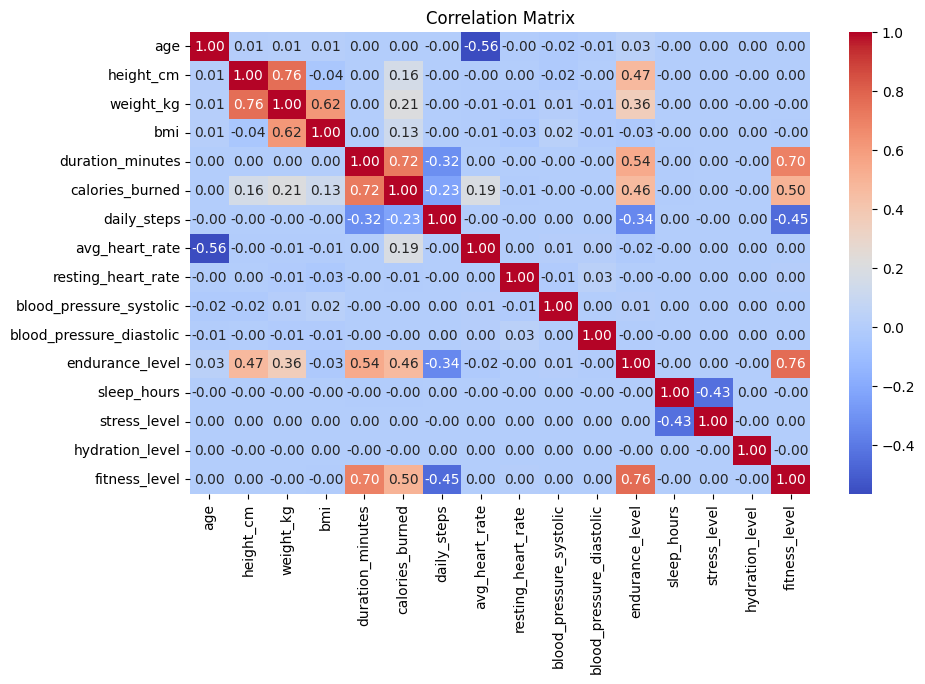

In [25]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=["int64","float64"]).corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [26]:
corr["calories_burned"].sort_values(ascending=False)

,calories_burned
calories_burned,1.000000
duration_minutes,0.720701
fitness_level,0.504665
endurance_level,0.462605
weight_kg,0.211222
avg_heart_rate,0.192532
height_cm,0.160999
bmi,0.128953
stress_level,0.003491
age,0.002955


In [27]:
df.groupby("intensity")["calories_burned"].mean()

,calories_burned
intensity,
High,655.084092
Low,389.245481
Medium,527.510109


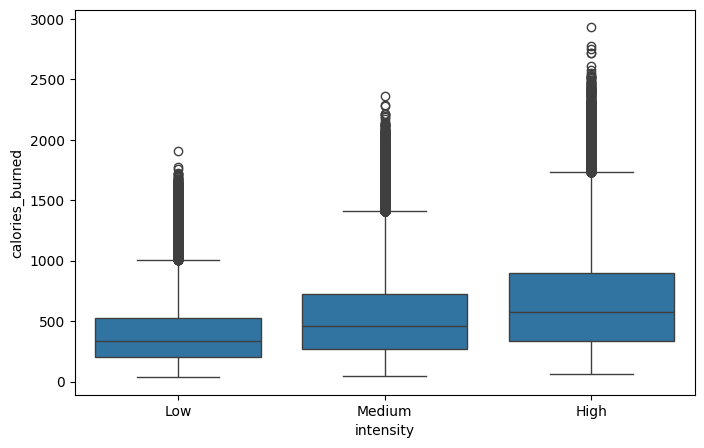

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot( data=df,x="intensity", y="calories_burned")

plt.show()

In [29]:
avg_calories = df.groupby("activity_type")["calories_burned"].mean().sort_values()
avg_calories_df = avg_calories.reset_index()

print(avg_calories_df)

     activity_type  calories_burned
0             Yoga       244.186264
1          Walking       278.983940
2  Weight Training       381.178853
3          Dancing       436.589133
4          Cycling       505.431192
5           Tennis       540.100648
6         Swimming       620.450162
7       Basketball       621.462455
8          Running       713.491462
9             HIIT       780.546711


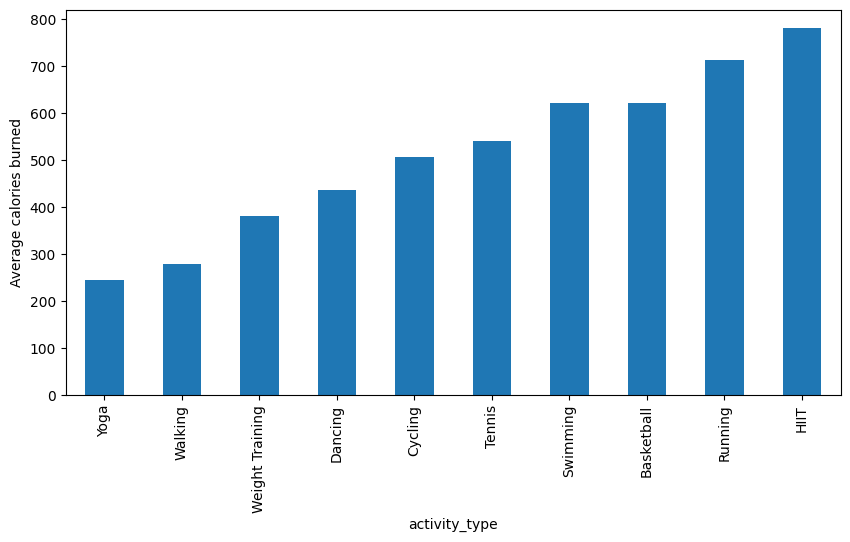

In [30]:
plt.figure(figsize=(10,5))

df.groupby("activity_type")["calories_burned"].mean().sort_values().plot(kind="bar")

plt.ylabel("Average calories burned")
plt.show()

## 6. Feature engineering

The following fields are engineered to create the modelling targets. They are excluded where they would reveal the target formula directly.

In [31]:
def assign_goal(row):
    if row["bmi"] >= 30:
        return "Lose Weight"
    elif row["bmi"] < 18.5:
        return "Gain Weight"
    else:
        return "Maintain Weight"

df["goal"] = df.apply(assign_goal, axis=1)

In [32]:
def calculate_activity_factor(row):
    if row["intensity"] == "Low" and row["daily_steps"] < 5000:
        return 1.2

    elif row["intensity"] == "Medium" or row["daily_steps"] < 10000:
        return 1.55

    else:
        return 1.725


df["activity_factor"] = df.apply(calculate_activity_factor, axis=1)

In [33]:
df["BMR"] = np.where(
    df["gender"] == "M",
    (10 * df["weight_kg"]) + (6.25 * df["height_cm"]) - (5 * df["age"]) + 5,
    (10 * df["weight_kg"]) + (6.25 * df["height_cm"]) - (5 * df["age"]) - 161
)

In [34]:
df["TDEE"] = df["BMR"] * df["activity_factor"]

In [35]:
df["required_calories"] = np.where(
    df["goal"] == "Lose Weight",
    df["TDEE"] - 500,
    np.where(
        df["goal"] == "Maintain Weight",
        df["TDEE"],
        df["TDEE"] + 300
    )
)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687699 entries, 0 to 687700
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       687699 non-null  int64  
 1   gender                    687699 non-null  object 
 2   height_cm                 687699 non-null  float64
 3   weight_kg                 687699 non-null  float64
 4   bmi                       687699 non-null  float64
 5   activity_type             687699 non-null  object 
 6   duration_minutes          687699 non-null  float64
 7   intensity                 687699 non-null  object 
 8   calories_burned           687699 non-null  float64
 9   daily_steps               687699 non-null  int64  
 10  avg_heart_rate            687699 non-null  int64  
 11  resting_heart_rate        687699 non-null  float64
 12  blood_pressure_systolic   687699 non-null  float64
 13  blood_pressure_diastolic  687699 non-null  float6

## 7. Shared modelling utilities

Categorical and numerical columns are identified **after** feature selection. Each categorical column has its own `LabelEncoder`, fitted on the training split only. Unseen test categories are encoded as `-1` so the evaluation step remains robust without leaking test labels.

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.20


def encode_categorical_features(X_train, X_test, categorical_columns):
    """Fit one LabelEncoder per feature on training data and encode both splits."""
    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()
    encoders = {}

    for column in categorical_columns:
        encoder = LabelEncoder()
        train_values = X_train_encoded[column].astype(str)
        test_values = X_test_encoded[column].astype(str)

        # Fit only on training data to avoid test-set information leakage.
        encoder.fit(train_values)
        X_train_encoded[column] = encoder.transform(train_values)

        # LabelEncoder does not natively support unknown labels. Preserve a safe
        # sentinel value for any category that was absent from training data.
        category_map = {label: index for index, label in enumerate(encoder.classes_)}
        X_test_encoded[column] = test_values.map(category_map).fillna(-1).astype(int)
        encoders[column] = encoder

    return X_train_encoded, X_test_encoded, encoders


def scale_numerical_features(X_train, X_test, numerical_columns):
    """Standardize only numerical predictors, using statistics from training data."""
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    scaler = StandardScaler()

    X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
    X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])
    return X_train_scaled, X_test_scaled, scaler


def evaluate_regression_model(model_name, y_train, train_predictions, y_test, test_predictions):
    """Print comparable train/test metrics for every regression model."""
    print(f"{model_name}")
    print(f"Train R²: {r2_score(y_train, train_predictions):.4f}")
    print(f"Train MAE: {mean_absolute_error(y_train, train_predictions):.2f}")
    print(f"Test R²:  {r2_score(y_test, test_predictions):.4f}")
    print(f"Test MAE:  {mean_absolute_error(y_test, test_predictions):.2f}")


def plot_actual_vs_predicted(y_true, predictions, target_label, model_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, predictions, alpha=0.45)
    lower_bound = min(y_true.min(), predictions.min())
    upper_bound = max(y_true.max(), predictions.max())
    plt.plot([lower_bound, upper_bound], [lower_bound, upper_bound], "r--", label="Perfect prediction")
    plt.xlabel(f"Actual {target_label}")
    plt.ylabel(f"Predicted {target_label}")
    plt.title(f"{model_name}: Actual vs Predicted {target_label}")
    plt.legend()
    plt.show()


# Module 1 — Predict Required Calories

## 8. Feature selection and preprocessing

`BMR`, `TDEE`, `activity_factor`, and `goal` are excluded because they are intermediate values or direct inputs to the formula used to create `required_calories`. Keeping them would make the model learn the target construction rather than make an independent prediction.

In [38]:
# Remove rows with missing values before splitting into predictors and target.
df_cleaned = df.dropna().copy()

REQUIRED_CALORIES_EXCLUDED_COLUMNS = [
    "required_calories",  # Prediction target
    "BMR",                # Direct component of TDEE
    "TDEE",               # Direct component of required_calories
    "activity_factor",    # Direct component of TDEE
    "goal",               # Directly determines the calorie adjustment
]

X_required = df_cleaned.drop(columns=REQUIRED_CALORIES_EXCLUDED_COLUMNS)
y_required = df_cleaned["required_calories"]

# Detect feature types only after selecting the predictors.
categorical_features_required = X_required.select_dtypes(include="object").columns.tolist()
numerical_features_required = X_required.select_dtypes(include=["number"]).columns.tolist()

X_required_train, X_required_test, y_required_train, y_required_test = train_test_split(
    X_required,
    y_required,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_required_train_encoded, X_required_test_encoded, required_label_encoders = encode_categorical_features(
    X_required_train,
    X_required_test,
    categorical_features_required,
)

X_required_train_scaled, X_required_test_scaled, required_scaler = scale_numerical_features(
    X_required_train_encoded,
    X_required_test_encoded,
    numerical_features_required,
)

print(f"Required-calories feature matrix: {X_required.shape}")
print(f"Categorical features: {categorical_features_required}")


Required-calories feature matrix: (687699, 20)
Categorical features: ['gender', 'activity_type', 'intensity', 'smoking_status']


## 9. Linear Regression

Linear Regression — Required Calories
Train R²: 0.9096
Train MAE: 68.53
Test R²:  0.9102
Test MAE:  68.21


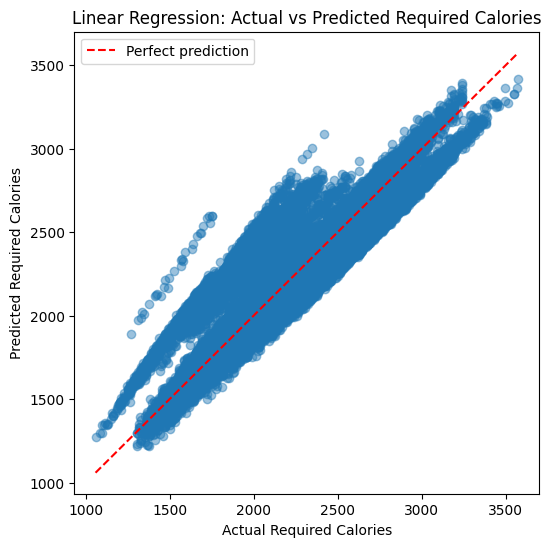

In [39]:
linear_required = LinearRegression()
linear_required.fit(X_required_train_scaled, y_required_train)

required_train_predictions_linear = linear_required.predict(X_required_train_scaled)
required_test_predictions_linear = linear_required.predict(X_required_test_scaled)

evaluate_regression_model(
    "Linear Regression — Required Calories",
    y_required_train,
    required_train_predictions_linear,
    y_required_test,
    required_test_predictions_linear,
)
plot_actual_vs_predicted(
    y_required_test,
    required_test_predictions_linear,
    "Required Calories",
    "Linear Regression",
)


## 10. XGBoost Regressor

XGBoost — Required Calories
Train R²: 0.9974
Train MAE: 11.18
Test R²:  0.9972
Test MAE:  11.42


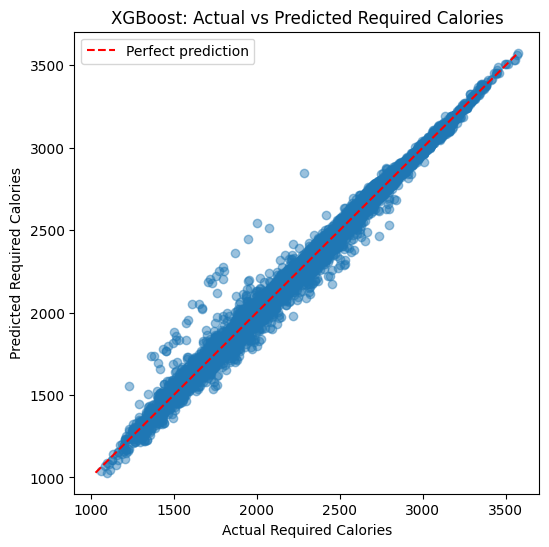

In [40]:
xgb_required = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_required.fit(X_required_train_encoded, y_required_train)

required_train_predictions_xgb = xgb_required.predict(X_required_train_encoded)
required_test_predictions_xgb = xgb_required.predict(X_required_test_encoded)

evaluate_regression_model(
    "XGBoost — Required Calories",
    y_required_train,
    required_train_predictions_xgb,
    y_required_test,
    required_test_predictions_xgb,
)
plot_actual_vs_predicted(
    y_required_test,
    required_test_predictions_xgb,
    "Required Calories",
    "XGBoost",
)


## 11. Random Forest Regressor

Random Forest — Required Calories
Train R²: 0.9997
Train MAE: 1.08
Test R²:  0.9978
Test MAE:  2.86


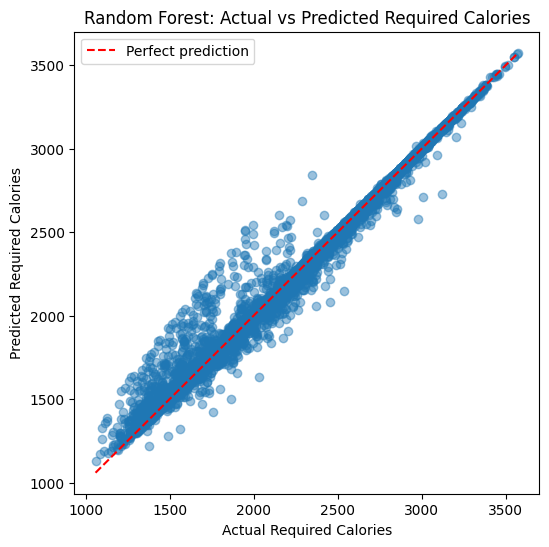

In [41]:
random_forest_required = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_required.fit(X_required_train_encoded, y_required_train)

required_train_predictions_rf = random_forest_required.predict(X_required_train_encoded)
required_test_predictions_rf = random_forest_required.predict(X_required_test_encoded)

evaluate_regression_model(
    "Random Forest — Required Calories",
    y_required_train,
    required_train_predictions_rf,
    y_required_test,
    required_test_predictions_rf,
)
plot_actual_vs_predicted(
    y_required_test,
    required_test_predictions_rf,
    "Required Calories",
    "Random Forest",
)


# Module 2 — Predict Calories Burned

## 12. Feature selection and preprocessing

This module uses the same preprocessing workflow. Derived calorie-planning fields are excluded to keep the problem independent from Module 1 and avoid proxy features. The remaining raw activity and personal attributes are available at prediction time.

In [42]:
CALORIES_BURNED_EXCLUDED_COLUMNS = [
    "calories_burned",    # Prediction target
    "required_calories",  # Output of the separate calorie-planning task
    "BMR",                # Derived calorie-planning intermediate
    "TDEE",               # Derived calorie-planning intermediate
    "activity_factor",    # Derived calorie-planning intermediate
    "goal",               # Derived calorie-planning category
]

X_burned = df_cleaned.drop(columns=CALORIES_BURNED_EXCLUDED_COLUMNS)
y_burned = df_cleaned["calories_burned"]

# Detect feature types only after selecting the predictors.
categorical_features_burned = X_burned.select_dtypes(include="object").columns.tolist()
numerical_features_burned = X_burned.select_dtypes(include=["number"]).columns.tolist()

X_burned_train, X_burned_test, y_burned_train, y_burned_test = train_test_split(
    X_burned,
    y_burned,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_burned_train_encoded, X_burned_test_encoded, burned_label_encoders = encode_categorical_features(
    X_burned_train,
    X_burned_test,
    categorical_features_burned,
)

X_burned_train_scaled, X_burned_test_scaled, burned_scaler = scale_numerical_features(
    X_burned_train_encoded,
    X_burned_test_encoded,
    numerical_features_burned,
)

print(f"Calories-burned feature matrix: {X_burned.shape}")
print(f"Categorical features: {categorical_features_burned}")


Calories-burned feature matrix: (687699, 19)
Categorical features: ['gender', 'activity_type', 'intensity', 'smoking_status']


## 13. Linear Regression

Linear Regression — Calories Burned
Train R²: 0.7129
Train MAE: 142.00
Test R²:  0.7127
Test MAE:  141.86


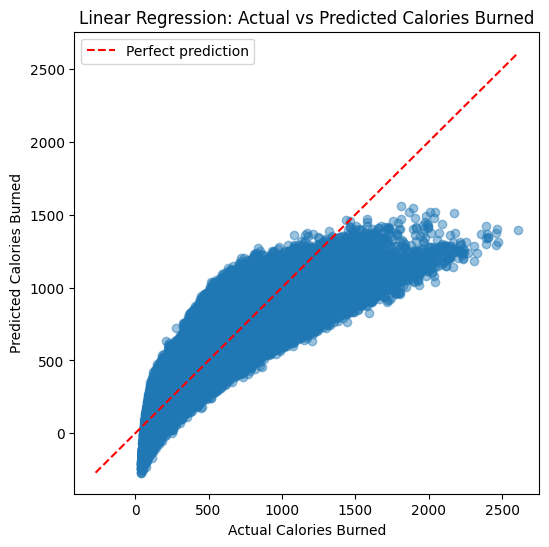

In [43]:
linear_burned = LinearRegression()
linear_burned.fit(X_burned_train_scaled, y_burned_train)

burned_train_predictions_linear = linear_burned.predict(X_burned_train_scaled)
burned_test_predictions_linear = linear_burned.predict(X_burned_test_scaled)

evaluate_regression_model(
    "Linear Regression — Calories Burned",
    y_burned_train,
    burned_train_predictions_linear,
    y_burned_test,
    burned_test_predictions_linear,
)
plot_actual_vs_predicted(
    y_burned_test,
    burned_test_predictions_linear,
    "Calories Burned",
    "Linear Regression",
)


## 14. XGBoost Regressor

XGBoost — Calories Burned
Train R²: 0.9985
Train MAE: 9.53
Test R²:  0.9984
Test MAE:  9.61


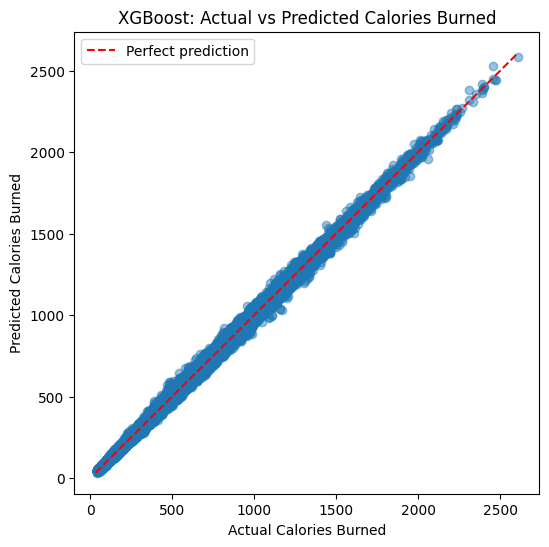

In [44]:
xgb_burned = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_burned.fit(X_burned_train_encoded, y_burned_train)

burned_train_predictions_xgb = xgb_burned.predict(X_burned_train_encoded)
burned_test_predictions_xgb = xgb_burned.predict(X_burned_test_encoded)

evaluate_regression_model(
    "XGBoost — Calories Burned",
    y_burned_train,
    burned_train_predictions_xgb,
    y_burned_test,
    burned_test_predictions_xgb,
)
plot_actual_vs_predicted(
    y_burned_test,
    burned_test_predictions_xgb,
    "Calories Burned",
    "XGBoost",
)


## 15. Random Forest Regressor

In [ ]:
random_forest_burned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_burned.fit(X_burned_train_encoded, y_burned_train)

burned_train_predictions_rf = random_forest_burned.predict(X_burned_train_encoded)
burned_test_predictions_rf = random_forest_burned.predict(X_burned_test_encoded)

evaluate_regression_model(
    "Random Forest — Calories Burned",
    y_burned_train,
    burned_train_predictions_rf,
    y_burned_test,
    burned_test_predictions_rf,
)
plot_actual_vs_predicted(
    y_burned_test,
    burned_test_predictions_rf,
    "Calories Burned",
    "Random Forest",
)
